# RF2-C — Field-wise semantic ablation

| 항목 | 값 |
|---|---|
| research_question | 페이지의 semantic information 이 정확히 어느 evidence field 에 있는가. 전체 페이지 텍스트보다 primary controls / accessibility text 가 더 informative 한가 |
| parent program | `RQ-D-RF-002` |
| child_id | `D-RF2-C` |
| hypothesis_id | `H-RF2-C-FIELD-INFORMATION` |
| competing hypotheses | H-C1 `text_blob` 전체가 최선 / H-C2 primary controls·accessibility text 가 더 informative / H-C3 field 간 차이가 prototype 노이즈보다 작다 |
| input snapshot sha — `D_TEXT_CORPUS_v2.csv` | `bf6bb772faa45541c780c75f5cbffa856783a34661a84e3de27a9eb5da4ea36a` |
| input snapshot sha — `D_TEXT_CORPUS.csv` (v1, §7 대조 전용) | `00420e0b68e4a762bd524040594268deae41bf4e8fac2d887c6b2b3d252c5ad8` |
| input snapshot sha — `D_OBSERVATION_TABLE_v2.csv` | `c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b` |
| code sha — `tools/rf2_c_field_ablation.py` | `ab9ac6e4cb3a7f0faad187149c5319a09eef64975cb2238733ec35e5fe9153cb` |
| result sha — `results/RF2_C_field_ablation.json` | `1ad4bdec4cc72208a4ed48e0ef8709d096cc44451a624f3cc3f692129971c896` |
| MLflow run_id | `4f8169a5956d4230be5a35f1f364c985` |
| MLflow parent_run_id | `ae754858ba3a4be391e5f811640d3fd8` (experiment `LA_03_RF_MAPPING`) |
| n | **56** (grain: **target**, `in_mart == 1`) |
| grain | target — 1 target = 1 L0 landing state |
| seed | `20260827` (permutation P=20000, stratified MC=20000) |
| 사용 모델 | `BAAI/bge-m3` (PRIMARY, max_seq 8192) · `intfloat/multilingual-e5-small` (`passage:`/`query:` 규약 준수) · `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` — 전부 로컬 캐시, 네트워크 다운로드 없음 (`HF_HUB_OFFLINE=1`) |
| PRIMARY config | `bge-m3 × prototype set A_SSOT_DEF`, 판정 기준선 = **stratified** |

## 라벨 의미 — 먼저 읽을 것

`prior_archetype` 은 **gold label 이 아니라 business-domain prior** 다. 따라서 이 노트북의 어떤
수치도 accuracy 가 아니며 전부 **`prior_agreement`** 다. `prior_archetype` 은 service identity 에서
유도됐으므로, brand 를 담은 field 의 높은 agreement 는 순환일 수 있다 — 이를 §7 post-hoc 진단에서
직접 검사한다.

`most_frequent`(항상 ITEM_DETAIL) 대비 macro F1 lift 는 **rigged 비교다**. majority 는 6/7 class 에서
recall 0 이라 macro F1 이 구조적으로 0.09 다. **판정 기준선은 `stratified`** 이고 `most_frequent` 는
참고로만 병기한다.

## 이 노트북이 하는 일

`results/RF2_C_field_ablation.json` 을 **읽어서** 표와 그림을 렌더한다. 계산은 하지 않는다
(모델 인코딩은 `tools/rf2_c_field_ablation.py` 에서만 일어난다). Restart → Run All 로 재현 가능하다.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/"
          "research/landing_accessibility/research_d")
D = json.loads((RD / "results" / "RF2_C_field_ablation.json").read_text(encoding="utf-8"))
FIG = RD / "figures"

PM, PS = D["primary_config"]["model"], D["primary_config"]["prototype_set"]
PRIM = D["grid"][PM][PS]
TOK = D["token_stats"][PM]
STRAT = D["baselines"]["stratified"]
REPS = [r["representation"] for r in D["field_ranking_primary"]]

print("VERDICT           :", D["verdict"])
print("n / grain         :", D["n"], "/", D["grain"])
print("class counts      :", D["class_counts"])
print("PRIMARY config    :", PM, "x", PS, "| decision baseline:", D["primary_config"]["decision_baseline"])
print("target semantics  :", D["target_note"])
print()
for k, v in D["hypotheses"].items():
    print(f"  {v:22s} {k}")

VERDICT           : PARTIALLY_SUPPORTED
n / grain         : 56 / target (in_mart==1)
class counts      : {'QUERY': 4, 'CONTENT_OPEN': 3, 'ITEM_DETAIL': 26, 'PLACE_LOOKUP': 4, 'COMMUNICATION_ENTRY': 4, 'FINANCIAL_ACTION_ENTRY': 10, 'UTILITY_ENTRY': 5}
PRIMARY config    : bge-m3 x A_SSOT_DEF | decision baseline: stratified
target semantics  : prior_archetype 는 gold label 이 아니라 business-domain prior 다. 지표는 accuracy 가 아니라 prior_agreement 다.

  REFUTED                H-C1 text_blob 전체가 최선
  NOT_SUPPORTED          H-C2 primary controls·accessibility text 가 더 informative
  REFUTED                H-C3 field 간 차이가 prototype 노이즈보다 작다


## 1. 기준선

`most_frequent` 를 macro F1 판정에 쓰지 않는 이유가 아래 표에 그대로 보인다 — macro F1 0.091 은
"좋은 기준선"이 아니라 **구조적으로 낮을 수밖에 없는 값**이다.

In [2]:
mf = D["baselines"]["most_frequent"]
base = pd.DataFrame([
    {"baseline": "most_frequent (-> ITEM_DETAIL)", "macro_f1": mf["macro_f1"],
     "prior_agreement": mf["prior_agreement"], "판정에 사용": "아니오 (rigged)"},
    {"baseline": "stratified mean", "macro_f1": STRAT["macro_f1_mean"],
     "prior_agreement": STRAT["prior_agreement_mean"], "판정에 사용": "예"},
    {"baseline": "stratified p95", "macro_f1": STRAT["macro_f1_p95"],
     "prior_agreement": STRAT["prior_agreement_p95"], "판정에 사용": "예 (통과선)"},
    {"baseline": "stratified p99", "macro_f1": STRAT["macro_f1_p99"],
     "prior_agreement": np.nan, "판정에 사용": "참고"},
])
display(base)
print(mf["note"])

,baseline,macro_f1,prior_agreement,판정에 사용
0,most_frequent (-> ITEM_DETAIL),0.0906,0.4643,아니오 (rigged)
1,stratified mean,0.1386,0.2737,예
2,stratified p95,0.2217,0.3571,예 (통과선)
3,stratified p99,0.2621,NaN,참고


majority 는 6/7 class 에서 recall 0 이므로 macro F1 lift 의 판정 기준선이 될 수 없다. 참고용으로만 보고한다.


## 2. Prototype 세트 전문 (3세트, frozen)

**모든 field 에 동일한 세트를 적용했다.** field 마다 prototype 을 바꾸면 field 비교가 무너진다.
문장은 SSOT 정의에서만 유도했고 코퍼스를 보고 만들지 않았다.

In [3]:
print(D["prototype_provenance"], "\n")
print(D["prototype_policy"], "\n")
print(D["e5_prefix_convention"], "\n")
for sname, pset in D["prototype_sets"].items():
    print("=" * 100)
    print("prototype set", sname)
    for a, t in pset.items():
        print(f"  [{a}]")
        print(f"      {t}")

SSOT 00 §4 archetype 목록과 SSOT 01 §5 Stage-3 branch 정의문 / §7 Prototype texts 조항에서만 유도했다. D_TEXT_CORPUS 의 내용을 읽고 문구를 맞추지 않았다. D-RF-001-C 의 세트와 동일하며 이 run 에서 문구를 수정하지 않았다. 

모든 field 에 동일한 frozen 세트를 적용했다. field 별로 문구를 바꾸지 않았다. 

intfloat/multilingual-e5-small 은 asymmetric 규약을 지켰다: 페이지 텍스트에 'passage: ', prototype 에 'query: ' 를 붙였다. bge-m3 / MiniLM 은 prefix 를 쓰지 않는 것이 공식 규약이므로 붙이지 않았다. 

prototype set A_SSOT_DEF
  [QUERY]
      사용자가 검색 입력창에 자유 텍스트 질의를 입력하고 제출하여 검색 결과 목록 상태로 전환하는 것이 대표행동이다. 검색 입력 control, 검색 form, 검색 제출 버튼이 대표 표면이다. search box, search form, submit query, search results.
  [CONTENT_OPEN]
      이미 존재하는 기사, 영상, 콘텐츠 한 건을 목록에서 선택해 본문을 열거나 재생을 시작하는 것이 대표행동이다. 콘텐츠 카드 목록, 기사 본문, 미디어 재생이 대표 표면이다. article body, news, video playback, content card list.
  [ITEM_DETAIL]
      거래 대상 상품 한 건의 상세면에 들어가 상품명, 가격, 거래 control 의 존재를 확인하는 것이 대표행동이다. 반복되는 상품 카드 목록과 상품 상세 문서가 대표 표면이다. product name, price, cart, order, shopping mall, item detail page.
  [PLACE_LOOKUP]
      장소를 질의하거나 특정 장소의 상세면을 여는 

## 3. Field 정의 — 무엇을 무엇과 비교하는가

`text_blob__ALL` 이 대조군(12 field 전체)이고, `blob_minus__*` 12개는 §5 ablation 전용이다.
결합 규약은 `text_blob` 과 동일하다: 빈 field 는 생략하고 `" \n "` 으로 잇는다.

In [4]:
defs = pd.DataFrame([
    {"representation": r, "group": D["representation_definitions"][r]["group"],
     "n_fields": len(D["representation_definitions"][r]["fields"]),
     "fields": " + ".join(D["representation_definitions"][r]["fields"])}
    for r in D["representation_definitions"]
])
display(defs[defs["group"] != "loo"].sort_values(["group", "representation"]).reset_index(drop=True))
print("leave-one-out representations (ablation 전용):",
      int((defs["group"] == "loo").sum()))

,representation,group,n_fields,fields
0,accessibility_text,combo,4,aria_labels + form_labels + placeholders + inp...
1,content_body,combo,2,headings + card_texts
2,controls_plus_identity,combo,7,title + url_tokens + buttons + aria_labels + f...
3,first_screen_interaction,combo,3,buttons + aria_labels + placeholders
4,identity,combo,3,title + meta_description + url_tokens
5,nav_surface,combo,2,landmarks + nav_links
6,primary_controls,combo,5,buttons + aria_labels + form_labels + placehol...
7,ssot7_bundle,combo,8,title + headings + landmarks + aria_labels + b...
8,structure,combo,3,title + headings + landmarks
9,text_blob__ALL,control,12,title + meta_description + headings + landmark...


leave-one-out representations (ablation 전용): 12


## 4. Field 별 결과표 — PRIMARY (bge-m3 × set A)

`prior_agr` 분모는 항상 **56**. 해당 field 가 빈 target 은 `ABSTAIN` 으로 두고 오답 처리한다
(정보가 없으면 맞출 수 없다). non-empty 조건부 수치는 별도 열에 자체 분모와 함께 있다.

`stab` = 3개 prototype 세트에 걸친 macro F1 range. `perm_p` = prior 셔플 permutation null(P=20000)
대비 p-value.

In [5]:
rows = []
for r in REPS:
    g, t = PRIM[r], TOK[r]
    st = D["prototype_stability"][PM]["per_representation"][r]
    lo, hi = g["prior_agreement_all56_wilson95"]
    rows.append({
        "representation": r, "group": D["representation_definitions"][r]["group"],
        "macro_f1": g["macro_f1"],
        "prior_agr(56)": g["prior_agreement_all56"],
        "n_agree": f'{g["n_agree_all56"]}/56',
        "wilson95": f"{lo:.3f}-{hi:.3f}",
        "empty": g["n_empty"],
        "cond_agr": g["prior_agreement_nonempty"],
        "cond_n": f'{g["n_agree_nonempty"]}/{g["n_nonempty"]}',
        "tok_med": t["tokens_median"], "trunc": t["truncation_rate"],
        "margin_med": g["margin_median"],
        "perm_p": g["perm_null"]["macro_f1_p_value"],
        "perm_z": g["perm_null"]["macro_f1_z"],
        "stab": st["macro_f1_range"],
        ">strat_p95": "Y" if g["beats_stratified_p95_macro_f1"] else "-",
    })
tab = pd.DataFrame(rows)
display(tab)

print(f'truncation: max_seq={TOK["text_blob__ALL"]["model_max_seq"]} 에서 초과 representation 수 =',
      int((tab["trunc"] > 0).sum()), "/", len(tab))
print("margin 중앙값 범위:", round(tab["margin_med"].min(), 4), "-", round(tab["margin_med"].max(), 4),
      "→ margin 은 field 를 구분하지 못한다")
print("permutation null 과 구별되지 않는 field (p>0.05):",
      list(tab.loc[tab["perm_p"] > 0.05, "representation"]))

,representation,group,macro_f1,prior_agr(56),n_agree,wilson95,empty,cond_agr,cond_n,tok_med,trunc,margin_med,perm_p,perm_z,stab,>strat_p95
0,title,single,0.5592,0.6071,34/56,0.476-0.724,1,0.6182,34/55,8.0,0.0,0.02366,0.00000,9.657,0.0810,Y
1,identity,combo,0.5561,0.6786,38/56,0.548-0.786,0,0.6786,38/56,29.0,0.0,0.02225,0.00000,9.475,0.0494,Y
2,text_blob__ALL,control,0.5088,0.6786,38/56,0.548-0.786,0,0.6786,38/56,498.5,0.0,0.02143,0.00000,8.984,0.1508,Y
3,meta_description,single,0.4964,0.5179,29/56,0.390-0.643,15,0.7073,29/41,26.0,0.0,0.02103,0.00000,9.055,0.1091,Y
4,content_body,combo,0.4490,0.5893,33/56,0.459-0.708,6,0.6600,33/50,220.5,0.0,0.02179,0.00000,7.780,0.1227,Y
5,nav_links,single,0.4378,0.4821,27/56,0.357-0.610,16,0.6750,27/40,106.5,0.0,0.02487,0.00000,7.851,0.1285,Y
6,headings,single,0.4356,0.4821,27/56,0.357-0.610,9,0.5745,27/47,62.0,0.0,0.02195,0.00000,7.422,0.1315,Y
7,ssot7_bundle,combo,0.4328,0.6607,37/56,0.530-0.771,0,0.6607,37/56,390.5,0.0,0.02166,0.00000,7.116,0.1008,Y
8,structure,combo,0.4209,0.6429,36/56,0.512-0.755,1,0.6545,36/55,136.0,0.0,0.02407,0.00000,6.926,0.0981,Y
9,card_texts,single,0.4200,0.5536,31/56,0.424-0.676,9,0.6596,31/47,181.0,0.0,0.02397,0.00000,7.366,0.0984,Y


truncation: max_seq=8192 에서 초과 representation 수 = 0 / 22
margin 중앙값 범위: 0.0158 - 0.0364 → margin 은 field 를 구분하지 못한다
permutation null 과 구별되지 않는 field (p>0.05): ['input_names', 'form_labels']


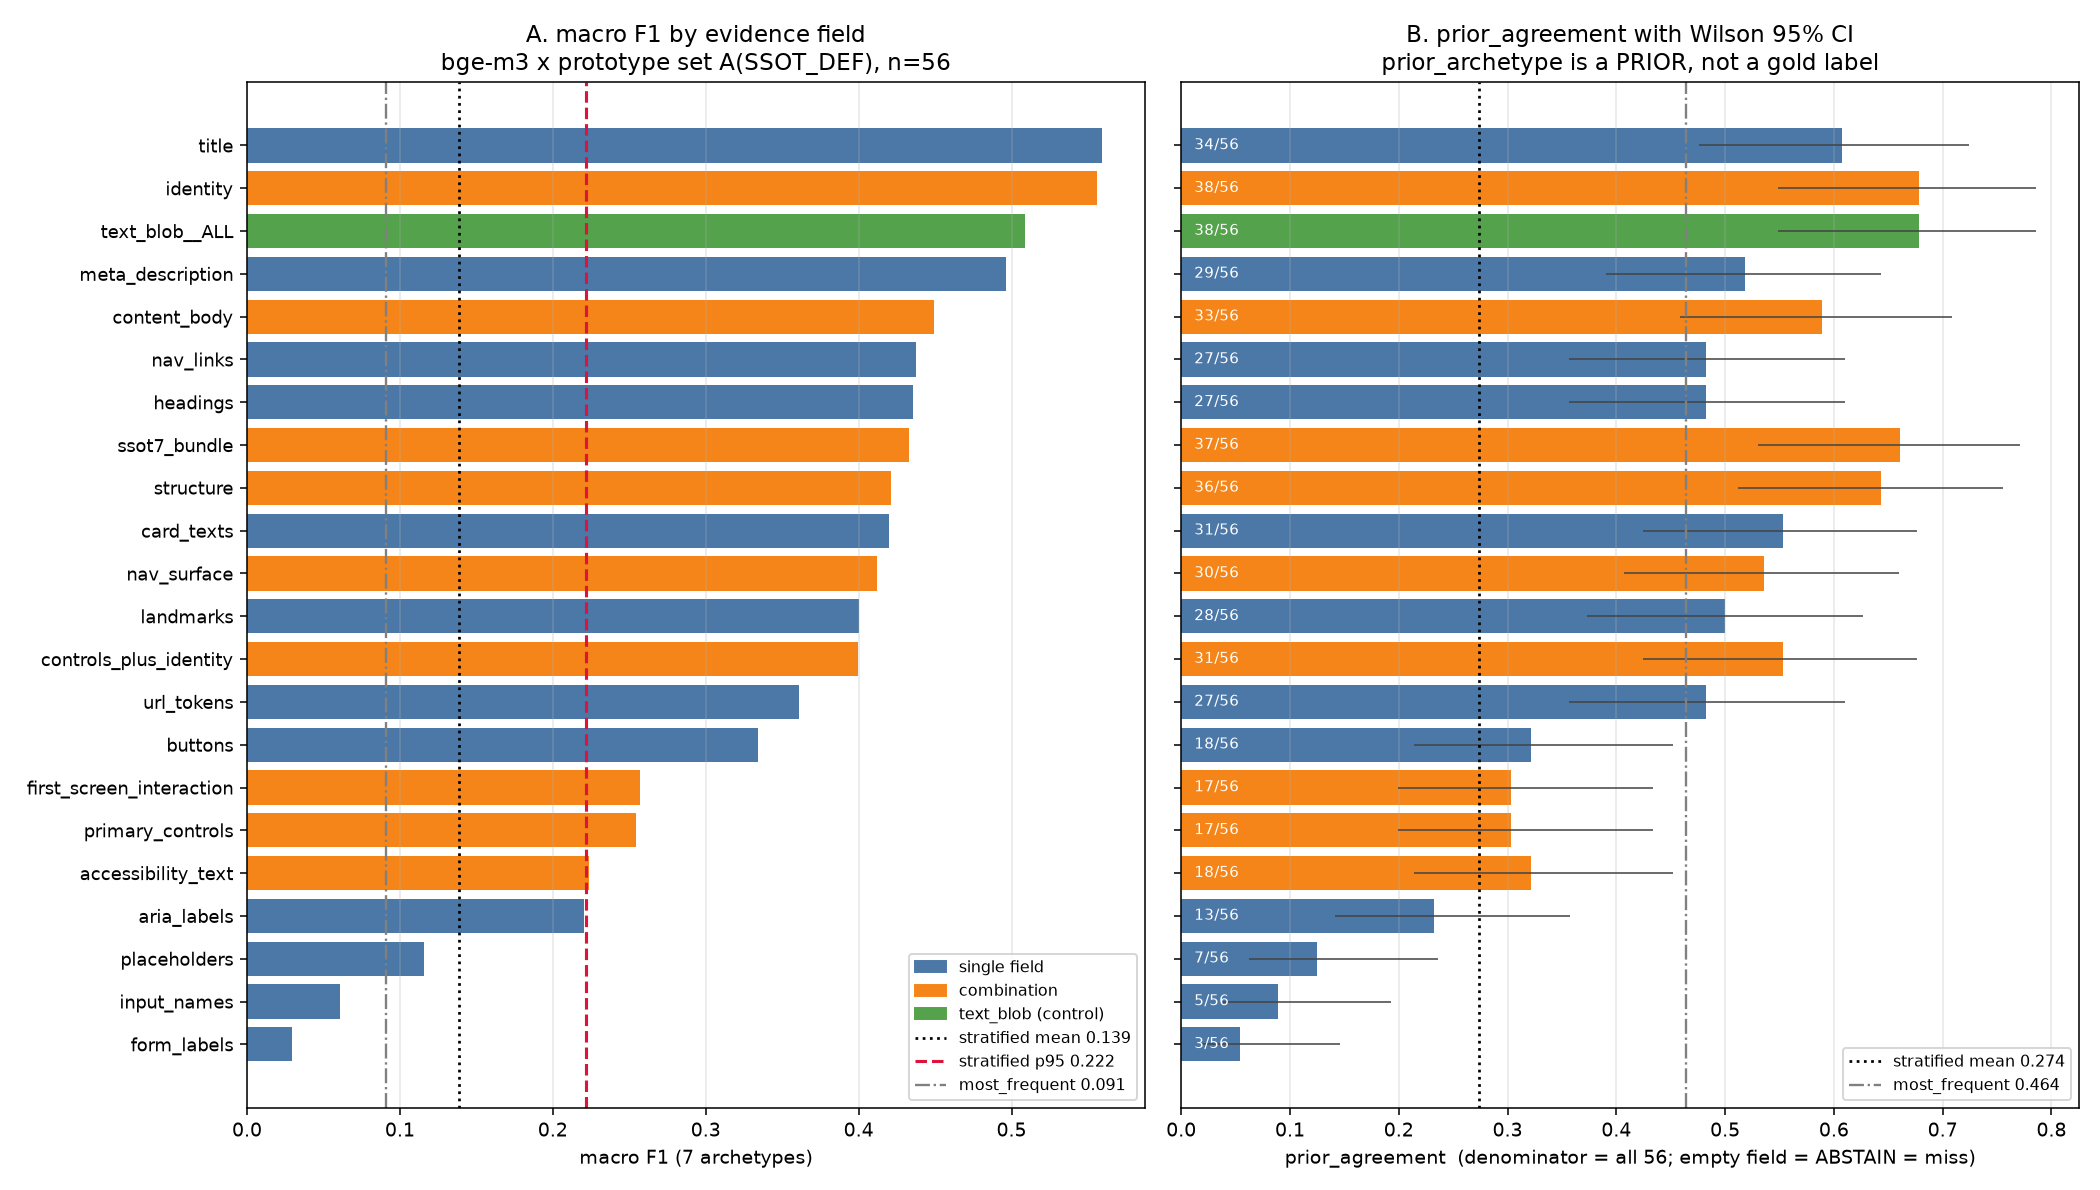

In [6]:
display(Image(filename=str(FIG / "RF2_C_field_ranking.png")))

### 4.1 반드시 답할 질문

> **전체 페이지 텍스트보다 primary controls / accessibility text 가 더 informative 한가?**

In [7]:
ctrl = ["primary_controls", "first_screen_interaction", "accessibility_text",
        "buttons", "aria_labels", "form_labels", "placeholders", "input_names"]
q = tab.set_index("representation")
blob = q.loc["text_blob__ALL"]
comp = q.loc[["text_blob__ALL"] + ctrl,
             ["macro_f1", "prior_agr(56)", "n_agree", "empty", "cond_agr", "perm_p", ">strat_p95"]]
display(comp)
best_ctrl = q.loc[ctrl, "macro_f1"].idxmax()
print(f'text_blob macro F1        = {blob["macro_f1"]:.3f}   prior_agreement = {blob["n_agree"]}')
print(f'controls 계열 최고 ({best_ctrl}) = {q.loc[best_ctrl, "macro_f1"]:.3f}   '
      f'prior_agreement = {q.loc[best_ctrl, "n_agree"]}')
print(f'stratified p95            = {STRAT["macro_f1_p95"]:.3f}')
print()
print("답: 아니다. controls 계열은 전부 text_blob 의 절반 이하이며 stratified p95 근처에 있다.")
print("→ H-C2 =", D["hypotheses"]["H-C2 primary controls·accessibility text 가 더 informative"])
print()
print("혼자서 text_blob 에 필적하는 representation (macro F1 >= text_blob):")
display(q.loc[q["macro_f1"] >= blob["macro_f1"], ["group", "macro_f1", "prior_agr(56)", "n_agree", "tok_med"]])

,macro_f1,prior_agr(56),n_agree,empty,cond_agr,perm_p,>strat_p95
representation,,,,,,,
text_blob__ALL,0.5088,0.6786,38/56,0,0.6786,0.00000,Y
primary_controls,0.2543,0.3036,17/56,5,0.3333,0.00215,Y
first_screen_interaction,0.2572,0.3036,17/56,7,0.3469,0.00175,Y
accessibility_text,0.2239,0.3214,18/56,7,0.3673,0.00580,Y
buttons,0.3341,0.3214,18/56,12,0.4091,0.00005,Y
aria_labels,0.2204,0.2321,13/56,20,0.3611,0.00115,-
form_labels,0.0296,0.0536,3/56,39,0.1765,0.61145,-
placeholders,0.1155,0.1250,7/56,34,0.3182,0.01360,-
input_names,0.0606,0.0893,5/56,31,0.2000,0.61345,-


text_blob macro F1        = 0.509   prior_agreement = 38/56
controls 계열 최고 (buttons) = 0.334   prior_agreement = 18/56
stratified p95            = 0.222

답: 아니다. controls 계열은 전부 text_blob 의 절반 이하이며 stratified p95 근처에 있다.
→ H-C2 = NOT_SUPPORTED

혼자서 text_blob 에 필적하는 representation (macro F1 >= text_blob):


,group,macro_f1,prior_agr(56),n_agree,tok_med
representation,,,,,
title,single,0.5592,0.6071,34/56,8.0
identity,combo,0.5561,0.6786,38/56,29.0
text_blob__ALL,control,0.5088,0.6786,38/56,498.5


## 5. Leave-one-field-out ablation

Δ = macro F1(`text_blob`) − macro F1(`text_blob` 에서 해당 field 제거).
**Δ > 0 = 그 field 가 blob 안에서 신호를 보탠다. Δ < 0 = 노이즈다.** 판정 임계 ±0.02 (사전 등록).

,field,delta_macro_f1,delta_prior_agr,field_alone_macro_f1,field_alone_prior_agr,verdict
0,nav_links,0.0609,0.0179,0.4378,0.4821,HELPS
1,buttons,0.0444,0.0000,0.3341,0.3214,HELPS
2,aria_labels,0.0350,0.0000,0.2204,0.2321,HELPS
3,meta_description,0.0330,0.0000,0.4964,0.5179,HELPS
4,form_labels,0.0303,0.0179,0.0296,0.0536,HELPS
5,landmarks,0.0146,0.0000,0.4003,0.5000,NEUTRAL
6,url_tokens,0.0063,0.0357,0.3610,0.4821,NEUTRAL
7,card_texts,0.0039,0.0000,0.4200,0.5536,NEUTRAL
8,title,-0.0178,-0.0357,0.5592,0.6071,NEUTRAL
9,input_names,-0.0724,-0.0357,0.0606,0.0893,NOISE


혼자서는 강한데 blob 안에서는 노이즈: ['headings']
혼자서는 null 수준인데 blob 안에서는 도움: ['form_labels'] (n=56 에서 1-2건 뒤집힘으로도 생기는 크기 — 과해석하지 않는다)


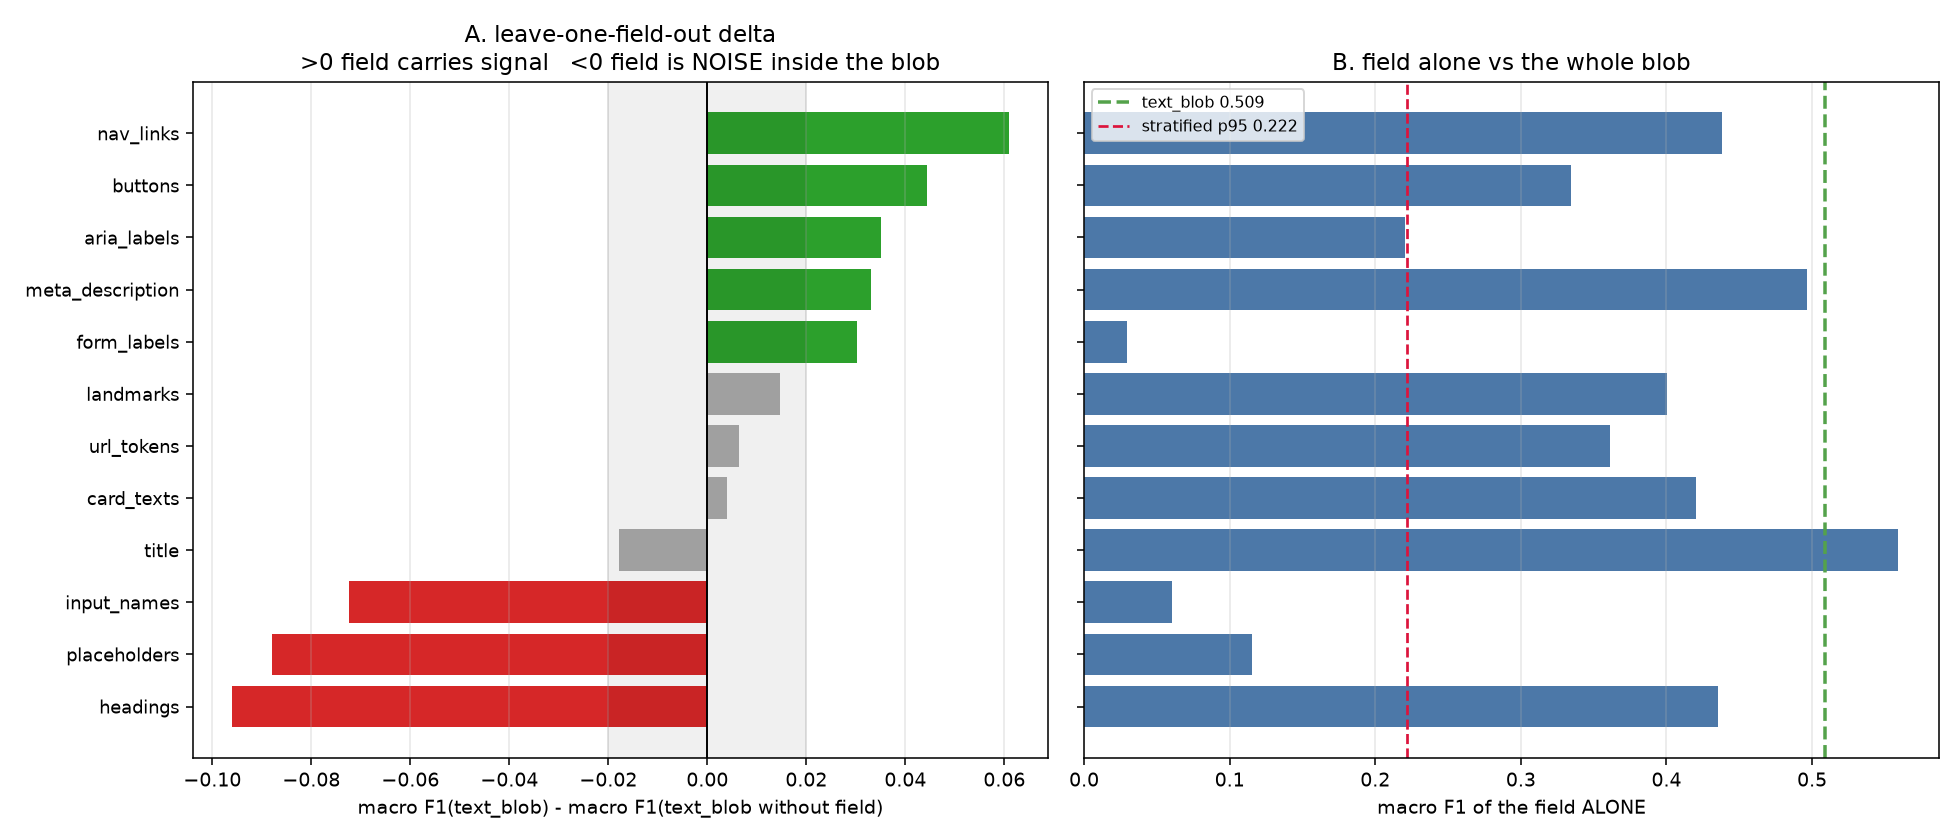

In [8]:
ab = D["ablation_leave_one_field_out"][PM][PS]
abt = pd.DataFrame([
    {"field": f, "delta_macro_f1": v["delta_macro_f1_removing_field"],
     "delta_prior_agr": v["delta_prior_agreement_removing_field"],
     "field_alone_macro_f1": v["field_alone_macro_f1"],
     "field_alone_prior_agr": v["field_alone_prior_agreement"],
     "verdict": v["verdict"]}
    for f, v in ab.items()
]).sort_values("delta_macro_f1", ascending=False).reset_index(drop=True)
display(abt)
print("혼자서는 강한데 blob 안에서는 노이즈:",
      list(abt.loc[(abt["verdict"] == "NOISE") & (abt["field_alone_macro_f1"] > 0.3), "field"]))
print("혼자서는 null 수준인데 blob 안에서는 도움:",
      list(abt.loc[(abt["verdict"] == "HELPS") & (abt["field_alone_macro_f1"] < 0.15), "field"]),
      "(n=56 에서 1-2건 뒤집힘으로도 생기는 크기 — 과해석하지 않는다)")
display(Image(filename=str(FIG / "RF2_C_ablation_delta.png")))

## 6. Prototype 문구 안정성 · 모델별 field 표 (H-C3)

**모델 비교가 primary 가 아니다.** field 순위가 모델/문구를 바꿔도 재현되는지를 본다.
표는 모델별로 분리한다.

In [9]:
for m in D["models"]:
    g = D["grid"][m][PS]
    r = sorted(REPS, key=lambda x: -g[x]["macro_f1"])
    t = pd.DataFrame([{"rank": i + 1, "representation": x, "macro_f1": g[x]["macro_f1"],
                       "prior_agr(56)": g[x]["prior_agreement_all56"],
                       "n_agree": f'{g[x]["n_agree_all56"]}/56'} for i, x in enumerate(r)])
    print("=" * 70)
    print(f"model = {m}   (prototype set {PS})")
    display(t.head(8))
    print("   text_blob__ALL rank :", r.index("text_blob__ALL") + 1,
          "| primary_controls rank :", r.index("primary_controls") + 1,
          "| accessibility_text rank :", r.index("accessibility_text") + 1)

model = bge-m3   (prototype set A_SSOT_DEF)


,rank,representation,macro_f1,prior_agr(56),n_agree
0,1,title,0.5592,0.6071,34/56
1,2,identity,0.5561,0.6786,38/56
2,3,text_blob__ALL,0.5088,0.6786,38/56
3,4,meta_description,0.4964,0.5179,29/56
4,5,content_body,0.4490,0.5893,33/56
5,6,nav_links,0.4378,0.4821,27/56
6,7,headings,0.4356,0.4821,27/56
7,8,ssot7_bundle,0.4328,0.6607,37/56


   text_blob__ALL rank : 3 | primary_controls rank : 17 | accessibility_text rank : 18
model = e5-small   (prototype set A_SSOT_DEF)


,rank,representation,macro_f1,prior_agr(56),n_agree
0,1,ssot7_bundle,0.4784,0.5000,28/56
1,2,text_blob__ALL,0.4577,0.5179,29/56
2,3,identity,0.4391,0.5714,32/56
3,4,structure,0.4353,0.5000,28/56
4,5,title,0.4316,0.5179,29/56
5,6,controls_plus_identity,0.4088,0.4643,26/56
6,7,meta_description,0.3917,0.3929,22/56
7,8,content_body,0.3649,0.4107,23/56


   text_blob__ALL rank : 2 | primary_controls rank : 13 | accessibility_text rank : 14
model = minilm   (prototype set A_SSOT_DEF)


,rank,representation,macro_f1,prior_agr(56),n_agree
0,1,text_blob__ALL,0.5433,0.6429,36/56
1,2,card_texts,0.4816,0.5000,28/56
2,3,content_body,0.4787,0.5357,30/56
3,4,structure,0.4682,0.5893,33/56
4,5,identity,0.4549,0.5179,29/56
5,6,ssot7_bundle,0.4459,0.5357,30/56
6,7,title,0.4365,0.4821,27/56
7,8,meta_description,0.4254,0.3929,22/56


   text_blob__ALL rank : 1 | primary_controls rank : 13 | accessibility_text rank : 12


,model,between_FIELD_sd,between_PROTOSET_sd,ratio_field/proto,field_range,rank_spearman_between_sets
0,bge-m3,0.1276,0.0384,3.32,0.5373,"{'A_SSOT_DEF~B_USER_BEHAVIOR': 0.677, 'A_SSOT_..."
1,e5-small,0.0977,0.1027,0.95,0.3554,"{'A_SSOT_DEF~B_USER_BEHAVIOR': 0.7519, 'A_SSOT..."
2,minilm,0.1418,0.0289,4.91,0.4831,"{'A_SSOT_DEF~B_USER_BEHAVIOR': 0.8637, 'A_SSOT..."


H-C3 = REFUTED
→ ratio > 1 인 모델에서는 field 효과가 문구 노이즈보다 크다. e5-small 은 ~1 이라 기각 불가.

prototype 세트에 따라 stratified p95 통과 여부가 뒤집히는 representation: ['buttons', 'aria_labels']


,representation,A_SSOT_DEF,B_USER_BEHAVIOR,C_TERSE_LABEL,rng
0,text_blob__ALL,0.5088,0.3865,0.5373,0.1508
1,title,0.5592,0.5141,0.4782,0.0810
2,identity,0.5561,0.5572,0.6055,0.0494
3,ssot7_bundle,0.4328,0.3320,0.4210,0.1008
4,buttons,0.3341,0.3126,0.2117,0.1224
5,aria_labels,0.2204,0.2733,0.2937,0.0733
6,primary_controls,0.2543,0.2937,0.3728,0.1185
7,first_screen_interaction,0.2572,0.3001,0.3579,0.1007
8,accessibility_text,0.2239,0.3024,0.2963,0.0785


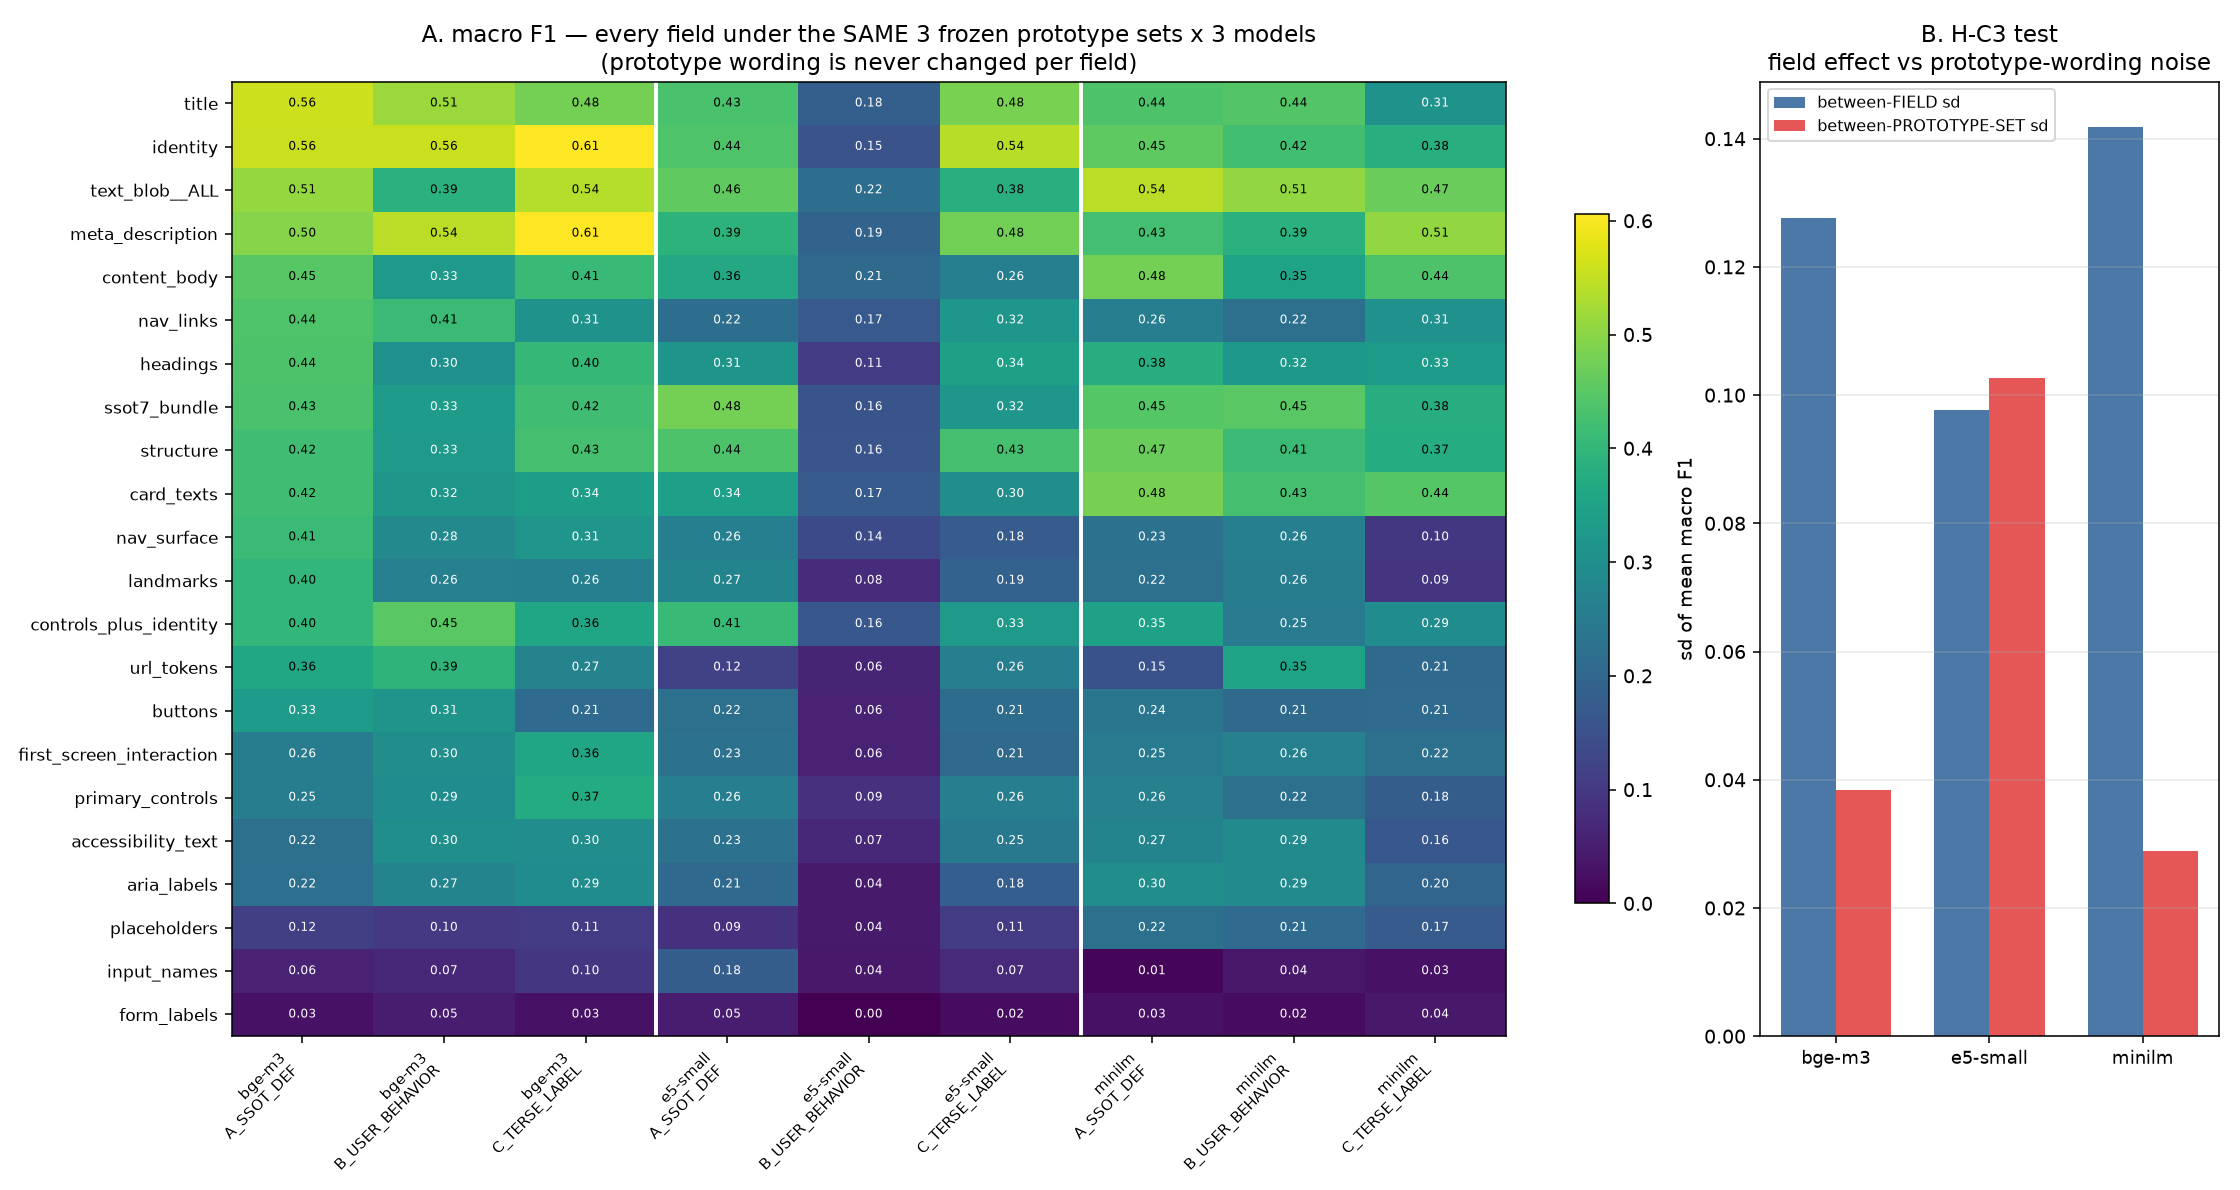

In [10]:
st = D["prototype_stability"]
stt = pd.DataFrame([
    {"model": m,
     "between_FIELD_sd": st[m]["between_field_sd_of_mean_macro_f1"],
     "between_PROTOSET_sd": st[m]["between_prototype_set_sd_of_mean_macro_f1"],
     "ratio_field/proto": round(st[m]["between_field_sd_of_mean_macro_f1"]
                                / st[m]["between_prototype_set_sd_of_mean_macro_f1"], 2),
     "field_range": st[m]["between_field_range"],
     "rank_spearman_between_sets": st[m]["field_rank_spearman_between_sets"]}
    for m in D["models"]])
display(stt)
print("H-C3 =", D["hypotheses"]["H-C3 field 간 차이가 prototype 노이즈보다 작다"])
print("→ ratio > 1 인 모델에서는 field 효과가 문구 노이즈보다 크다. e5-small 은 ~1 이라 기각 불가.")
print()
flips = [r for r in REPS if st[PM]["per_representation"][r]["verdict_flip_vs_stratified_p95"]]
print("prototype 세트에 따라 stratified p95 통과 여부가 뒤집히는 representation:", flips)
display(pd.DataFrame([dict(representation=r, **st[PM]["per_representation"][r]["macro_f1_by_set"],
                           rng=st[PM]["per_representation"][r]["macro_f1_range"])
                      for r in ["text_blob__ALL", "title", "identity", "ssot7_bundle"] + flips
                      + ["primary_controls", "first_screen_interaction", "accessibility_text"]]))
display(Image(filename=str(FIG / "RF2_C_prototype_stability.png")))

## 7. POST-HOC — 1위 field 의 우위는 브랜드 식별인가

> **사전 등록 항목이 아니다.** 결과를 본 뒤 추가한 confound 진단이며 prototype 문구도 임계값도
> 바꾸지 않았다. brand-masked 표현을 하나 더 평가했을 뿐이다.

`prior_archetype` ← business domain ← **service identity**. 그런데 상위 field 가 정확히 service
identity 를 담는다. 이걸 분리하지 않으면 순환이다.

POST_HOC_EXPLORATORY — 사전 등록 항목이 아니다. prototype 문구/임계값은 바뀌지 않았고 brand-masked 표현을 추가로 평가했을 뿐이다. 

prior_archetype 은 business domain prior 에서, business domain 은 service identity 에서 왔다. title 이 이기는 것이 상호작용 의미 때문인지 브랜드 식별 때문인지 분리하지 않으면 순환 논증이다. 

masking: prior_service 문자열 변형 + URL host 토큰(www/com/co/kr 등 제외)을 대소문자 무시로 모든 field 에서 제거
예시 마스킹 대상: {"쿠팡이츠": ["coupangeats", "쿠팡이츠"], "삼성카드": ["samsungcard", "삼성카드"], "GS25": ["gsretail", "gs25"]} 



,representation,as_collected,brand_masked,delta,delta_prior_agr
0,url_tokens,0.3610,0.1384,-0.2226,-0.2678
1,title,0.5592,0.3572,-0.2020,-0.2142
2,identity,0.5561,0.4109,-0.1452,-0.0893
3,buttons,0.3341,0.2234,-0.1107,-0.0535
4,landmarks,0.4003,0.3313,-0.0690,-0.0357
5,nav_surface,0.4118,0.3445,-0.0673,-0.0178
6,controls_plus_identity,0.3999,0.3357,-0.0642,-0.1072
7,primary_controls,0.2543,0.1969,-0.0574,-0.0357
8,meta_description,0.4964,0.4444,-0.0520,-0.0179
9,first_screen_interaction,0.2572,0.2081,-0.0491,-0.0357


brand-masked 순위 top8: ['text_blob__ALL', 'structure', 'content_body', 'meta_description', 'card_texts', 'headings', 'identity', 'nav_links']


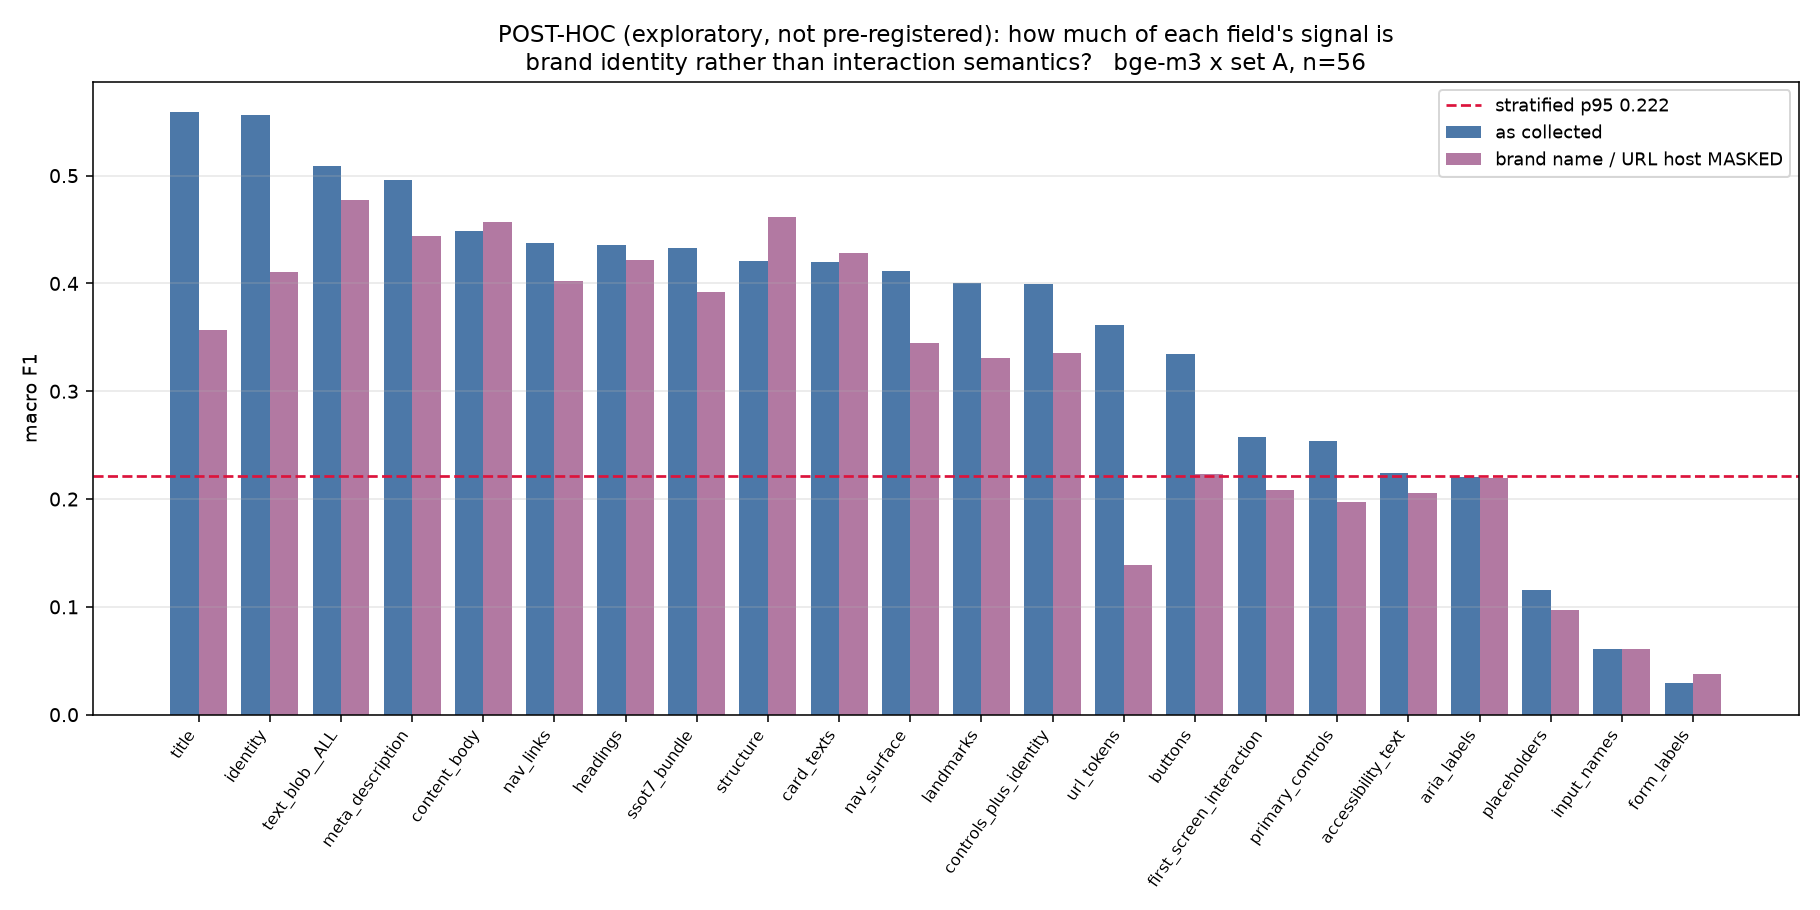

In [11]:
bm = D["posthoc_brand_masking"]
print(bm["status"], "\n")
print(bm["rationale"], "\n")
print("masking:", bm["masking"])
print("예시 마스킹 대상:", json.dumps(bm["example_terms"], ensure_ascii=False), "\n")
bt = pd.DataFrame([
    {"representation": r, "as_collected": PRIM[r]["macro_f1"],
     "brand_masked": v["macro_f1"], "delta": v["delta_macro_f1_vs_unmasked"],
     "delta_prior_agr": v["delta_prior_agreement_vs_unmasked"]}
    for r, v in bm["results"].items()]).sort_values("delta").reset_index(drop=True)
display(bt)
print("brand-masked 순위 top8:", bm["brand_masked_ranking"])
display(Image(filename=str(FIG / "RF2_C_brand_masking.png")))

## 8. Missingness · token length · margin

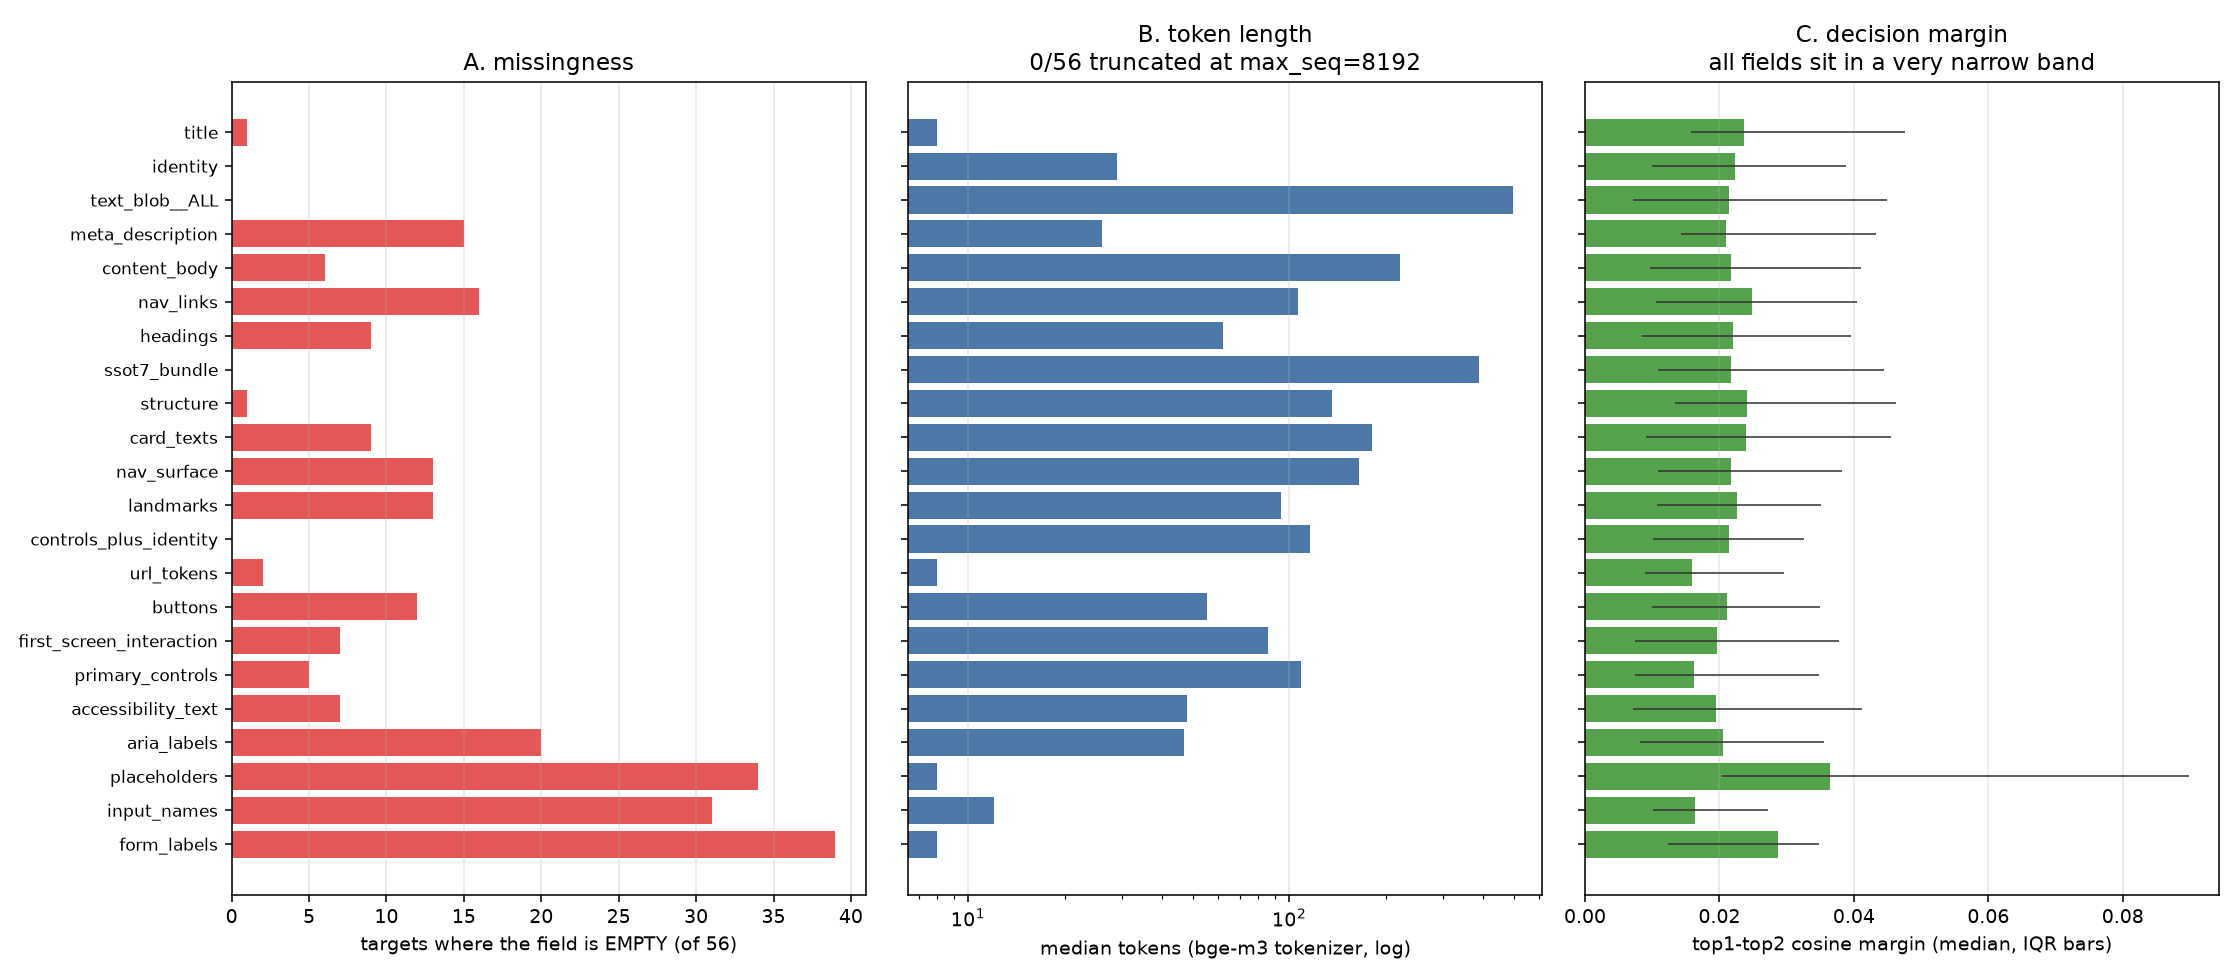

,representation,empty,tok_med,trunc,margin_med,prior_agr(56),cond_agr,cond_n,missingness_rate
0,form_labels,39,8.0,0.0,0.02878,0.0536,0.1765,3/17,0.696
1,placeholders,34,8.0,0.0,0.03644,0.1250,0.3182,7/22,0.607
2,input_names,31,12.0,0.0,0.01640,0.0893,0.2000,5/25,0.554
3,aria_labels,20,47.0,0.0,0.02058,0.2321,0.3611,13/36,0.357
4,nav_links,16,106.5,0.0,0.02487,0.4821,0.6750,27/40,0.286
5,meta_description,15,26.0,0.0,0.02103,0.5179,0.7073,29/41,0.268
6,landmarks,13,94.0,0.0,0.02268,0.5000,0.6512,28/43,0.232
7,nav_surface,13,165.0,0.0,0.02169,0.5357,0.6977,30/43,0.232
8,buttons,12,55.5,0.0,0.02113,0.3214,0.4091,18/44,0.214
9,headings,9,62.0,0.0,0.02195,0.4821,0.5745,27/47,0.161


주의: 정보가 없을수록 margin 이 커지는 역전이 있다 — form_labels empty=39/56 인데 margin 중앙값은 0.02878 로 전체 평균 0.0221 보다 높다.


In [12]:
display(Image(filename=str(FIG / "RF2_C_missingness_margin.png")))
mm = tab[["representation", "empty", "tok_med", "trunc", "margin_med",
          "prior_agr(56)", "cond_agr", "cond_n"]].copy()
mm["missingness_rate"] = (mm["empty"] / D["n"]).round(3)
display(mm.sort_values("empty", ascending=False).reset_index(drop=True))
print("주의: 정보가 없을수록 margin 이 커지는 역전이 있다 —",
      "form_labels empty=39/56 인데 margin 중앙값은", PRIM["form_labels"]["margin_median"],
      "로 전체 평균", round(float(np.mean([PRIM[r]["margin_median"] for r in REPS])), 4), "보다 높다.")

## 9. v1 → v2 인코딩 시정 효과

v1 코퍼스는 한글이 깨져 있었다. 동일 코드 · 동일 prototype · PRIMARY 모델로 v1 을 재계산해
인코딩 효과만 격리했다.

v1 은 한글 인코딩이 깨져 있었다. 동일 코드·동일 prototype 으로 v1/v2 를 PRIMARY 모델에서만 재계산해 인코딩 시정 효과를 격리한다. 

텍스트가 달라진 target: 8 / 56
field 별 변경 건수: {'title': 6, 'meta_description': 5, 'headings': 7, 'landmarks': 4, 'nav_links': 4, 'buttons': 7, 'aria_labels': 2, 'placeholders': 4, 'form_labels': 4, 'input_names': 0, 'card_texts': 7, 'url_tokens': 0}
blob_tokens 중앙값: 132.0 -> 173.5
rank-1 field: identity (v1) -> title (v2)  changed = True


,representation,v1_macro_f1,v2_macro_f1,delta_macro_f1,v1_n_agree,v2_n_agree
0,title,0.4344,0.5592,0.1248,29/56,34/56
1,controls_plus_identity,0.3068,0.3999,0.0931,28/56,31/56
2,card_texts,0.3576,0.4200,0.0624,27/56,31/56
3,headings,0.3805,0.4356,0.0551,25/56,27/56
4,nav_links,0.3904,0.4378,0.0474,25/56,27/56
5,identity,0.5159,0.5561,0.0402,37/56,38/56
6,content_body,0.4166,0.4490,0.0324,30/56,33/56
7,buttons,0.3040,0.3341,0.0301,17/56,18/56
8,primary_controls,0.2263,0.2543,0.0280,16/56,17/56
9,nav_surface,0.3869,0.4118,0.0249,28/56,30/56



짧은 field 일수록 인코딩 결함의 피해가 컸다 — text_blob 하나만 봤다면 +0.0118 로 과소평가했을 것이다.


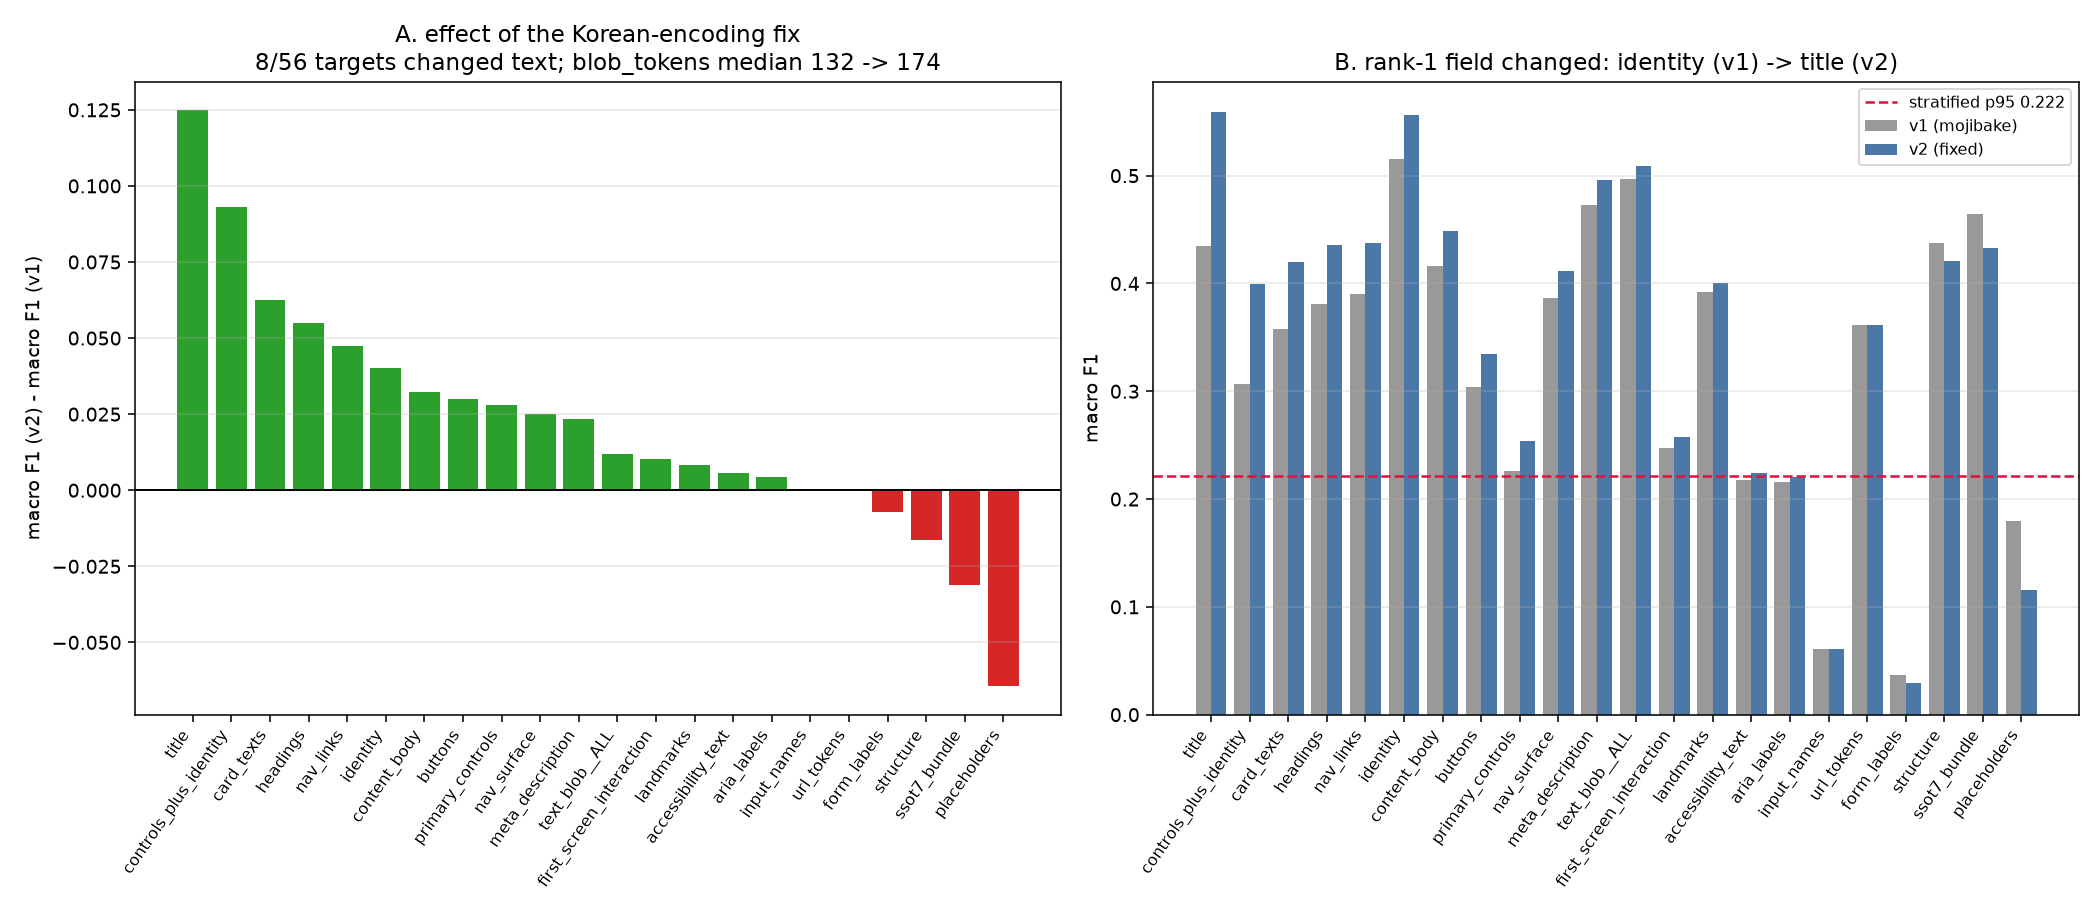

In [13]:
v = D["v1_vs_v2_encoding_fix"]
print(v["note"], "\n")
print("텍스트가 달라진 target:", v["n_targets_with_changed_field"]["any_field"], "/", D["n"])
print("field 별 변경 건수:", v["n_targets_with_changed_field"]["per_field"])
print("blob_tokens 중앙값:", v["blob_tokens_median_v1"], "->", v["blob_tokens_median_v2"])
print("rank-1 field:", v["top5_v1"][0], "(v1) ->", v["top5_v2"][0], "(v2)  changed =", v["rank_top1_changed"])
vt = pd.DataFrame([
    {"representation": r, "v1_macro_f1": v["primary_v1"][r]["macro_f1"],
     "v2_macro_f1": v["primary_v2"][r]["macro_f1"],
     "delta_macro_f1": v["delta_v2_minus_v1"][r]["macro_f1"],
     "v1_n_agree": f'{v["primary_v1"][r]["n_agree_all56"]}/56',
     "v2_n_agree": f'{v["primary_v2"][r]["n_agree_all56"]}/56'}
    for r in v["primary_v1"]]).sort_values("delta_macro_f1", ascending=False).reset_index(drop=True)
display(vt)
print("\n짧은 field 일수록 인코딩 결함의 피해가 컸다 — text_blob 하나만 봤다면",
      f'{v["delta_v2_minus_v1"]["text_blob__ALL"]["macro_f1"]:+.4f} 로 과소평가했을 것이다.')
display(Image(filename=str(FIG / "RF2_C_v1_v2_encoding.png")))

## 10. 반례

`text_blob__ALL` 과 controls 계열이 갈린 target. 방향의 비대칭이 H-C2 기각의 직접 증거다.

In [14]:
ce = pd.DataFrame(D["counterexamples"])
print("비교 대상:", D["counterexample_reference"])
print(ce["type"].value_counts().to_dict())
print("\ncontrols 가 이긴 사례 (반례로서 의미 있는 것):")
display(ce[ce["type"] == "controls_right_blob_wrong"].reset_index(drop=True))
print("\ncontrols 가 진 사례:")
display(ce[ce["type"] == "blob_right_controls_wrong"].reset_index(drop=True))

print("\nclass 수준 반례 — UTILITY_ENTRY (n=5):")
ut = pd.DataFrame([{"representation": r,
                    "UTILITY_ENTRY_tp": PRIM[r]["per_class"]["UTILITY_ENTRY"]["tp"],
                    "recall": PRIM[r]["per_class"]["UTILITY_ENTRY"]["recall"],
                    "wilson95": PRIM[r]["per_class"]["UTILITY_ENTRY"]["recall_wilson95"]}
                   for r in REPS])
display(ut.sort_values("UTILITY_ENTRY_tp", ascending=False).reset_index(drop=True))
print("n=5 이므로 과해석하지 않는다. 다만 22개 중 18개가 0/5 라는 사실은 prototype 문구 문제가")
print("아니라 archetype 정의가 텍스트 표면에 흔적을 남기지 않는 구조적 문제를 시사한다.")

비교 대상: {'blob': 'text_blob__ALL', 'controls': 'first_screen_interaction'}
{'blob_right_controls_wrong': 23, 'controls_right_blob_wrong': 2}

controls 가 이긴 사례 (반례로서 의미 있는 것):


,wtg,service,prior,blob_pred,first_screen_interaction_pred,type
0,5beeafeac2e27eae,TikTok,CONTENT_OPEN,COMMUNICATION_ENTRY,CONTENT_OPEN,controls_right_blob_wrong
1,6d5510a695d0a614,네이버,QUERY,ITEM_DETAIL,QUERY,controls_right_blob_wrong



controls 가 진 사례:


,wtg,service,prior,blob_pred,first_screen_interaction_pred,type
0,12e3942c0495b9a4,GS25,ITEM_DETAIL,ITEM_DETAIL,FINANCIAL_ACTION_ENTRY,blob_right_controls_wrong
1,22ffba7a86ea9919,코스트코,ITEM_DETAIL,ITEM_DETAIL,CONTENT_OPEN,blob_right_controls_wrong
2,64d30ef262d8782d,신한 SOL뱅크,FINANCIAL_ACTION_ENTRY,FINANCIAL_ACTION_ENTRY,ABSTAIN,blob_right_controls_wrong
3,65f15ce8fee25b24,밴드,COMMUNICATION_ENTRY,COMMUNICATION_ENTRY,PLACE_LOOKUP,blob_right_controls_wrong
4,8195b68ac17e42a3,세븐일레븐,ITEM_DETAIL,ITEM_DETAIL,ABSTAIN,blob_right_controls_wrong
5,dd2cec4c1fa2beec,롯데백화점,ITEM_DETAIL,ITEM_DETAIL,QUERY,blob_right_controls_wrong
6,e7bb158c1c8d9fe7,마켓컬리,ITEM_DETAIL,ITEM_DETAIL,FINANCIAL_ACTION_ENTRY,blob_right_controls_wrong
7,13ed070478ef62c3,Netflix,CONTENT_OPEN,CONTENT_OPEN,QUERY,blob_right_controls_wrong
8,5c614fc99631ce5e,홈앤쇼핑,ITEM_DETAIL,ITEM_DETAIL,UTILITY_ENTRY,blob_right_controls_wrong
9,699a5e2f3f410152,카카오톡,COMMUNICATION_ENTRY,COMMUNICATION_ENTRY,QUERY,blob_right_controls_wrong



class 수준 반례 — UTILITY_ENTRY (n=5):


,representation,UTILITY_ENTRY_tp,recall,wilson95
0,title,2,0.4,"[0.1176, 0.7693]"
1,controls_plus_identity,2,0.4,"[0.1176, 0.7693]"
2,headings,1,0.2,"[0.0362, 0.6245]"
3,identity,1,0.2,"[0.0362, 0.6245]"
4,text_blob__ALL,0,0.0,"[0.0, 0.4345]"
5,meta_description,0,0.0,"[0.0, 0.4345]"
6,nav_links,0,0.0,"[0.0, 0.4345]"
7,content_body,0,0.0,"[0.0, 0.4345]"
8,structure,0,0.0,"[0.0, 0.4345]"
9,ssot7_bundle,0,0.0,"[0.0, 0.4345]"


n=5 이므로 과해석하지 않는다. 다만 22개 중 18개가 0/5 라는 사실은 prototype 문구 문제가
아니라 archetype 정의가 텍스트 표면에 흔적을 남기지 않는 구조적 문제를 시사한다.


### 10.1 PRIMARY 의 class 별 성적 — `text_blob` vs `title`

n ≤ 5 class 는 Wilson CI 폭이 0.3~0.9 다. **개별 class 수치를 해석하지 않는다.**

In [15]:
for r in ["text_blob__ALL", "title", "identity", "primary_controls"]:
    pc = PRIM[r]["per_class"]
    print("=" * 60, r, f'(macro F1 {PRIM[r]["macro_f1"]:.3f})')
    display(pd.DataFrame([{"archetype": a, **v} for a, v in pc.items()]))

============================================================ text_blob__ALL (macro F1 0.509)


,archetype,n,tp,precision,recall,f1,recall_wilson95
0,QUERY,4,2,0.4000,0.5000,0.4444,"[0.15, 0.85]"
1,CONTENT_OPEN,3,1,0.5000,0.3333,0.4000,"[0.0615, 0.7923]"
2,ITEM_DETAIL,26,19,0.9500,0.7308,0.8261,"[0.5392, 0.863]"
3,PLACE_LOOKUP,4,3,0.4286,0.7500,0.5455,"[0.3006, 0.9544]"
4,COMMUNICATION_ENTRY,4,3,0.4286,0.7500,0.5455,"[0.3006, 0.9544]"
5,FINANCIAL_ACTION_ENTRY,10,10,0.6667,1.0000,0.8000,"[0.7225, 1.0]"
6,UTILITY_ENTRY,5,0,0.0000,0.0000,0.0000,"[0.0, 0.4345]"


============================================================ title (macro F1 0.559)


,archetype,n,tp,precision,recall,f1,recall_wilson95
0,QUERY,4,2,1.0000,0.5000,0.6667,"[0.15, 0.85]"
1,CONTENT_OPEN,3,2,0.2222,0.6667,0.3333,"[0.2077, 0.9385]"
2,ITEM_DETAIL,26,16,0.8889,0.6154,0.7273,"[0.4253, 0.7757]"
3,PLACE_LOOKUP,4,3,0.4286,0.7500,0.5455,"[0.3006, 0.9544]"
4,COMMUNICATION_ENTRY,4,2,0.2500,0.5000,0.3333,"[0.15, 0.85]"
5,FINANCIAL_ACTION_ENTRY,10,7,0.7778,0.7000,0.7368,"[0.3968, 0.8922]"
6,UTILITY_ENTRY,5,2,1.0000,0.4000,0.5714,"[0.1176, 0.7693]"


============================================================ identity (macro F1 0.556)


,archetype,n,tp,precision,recall,f1,recall_wilson95
0,QUERY,4,2,1.0000,0.5000,0.6667,"[0.15, 0.85]"
1,CONTENT_OPEN,3,1,0.2500,0.3333,0.2857,"[0.0615, 0.7923]"
2,ITEM_DETAIL,26,21,0.8750,0.8077,0.8400,"[0.6212, 0.9149]"
3,PLACE_LOOKUP,4,3,0.3750,0.7500,0.5000,"[0.3006, 0.9544]"
4,COMMUNICATION_ENTRY,4,3,0.5000,0.7500,0.6000,"[0.3006, 0.9544]"
5,FINANCIAL_ACTION_ENTRY,10,7,0.6364,0.7000,0.6667,"[0.3968, 0.8922]"
6,UTILITY_ENTRY,5,1,1.0000,0.2000,0.3333,"[0.0362, 0.6245]"


============================================================ primary_controls (macro F1 0.254)


,archetype,n,tp,precision,recall,f1,recall_wilson95
0,QUERY,4,3,0.1875,0.7500,0.3000,"[0.3006, 0.9544]"
1,CONTENT_OPEN,3,1,0.2500,0.3333,0.2857,"[0.0615, 0.7923]"
2,ITEM_DETAIL,26,8,0.8000,0.3077,0.4444,"[0.165, 0.4999]"
3,PLACE_LOOKUP,4,3,0.3750,0.7500,0.5000,"[0.3006, 0.9544]"
4,COMMUNICATION_ENTRY,4,0,0.0000,0.0000,0.0000,"[0.0, 0.4899]"
5,FINANCIAL_ACTION_ENTRY,10,2,0.3333,0.2000,0.2500,"[0.0567, 0.5098]"
6,UTILITY_ENTRY,5,0,0.0000,0.0000,0.0000,"[0.0, 0.4345]"


## 11. Verdict · limitation · firewall

In [16]:
print("VERDICT:", D["verdict"], "\n")
for k, val in D["hypotheses"].items():
    print(f"  {val:22s} {k}")
print("\nheadline:")
print(json.dumps(D["headline"], ensure_ascii=False, indent=1))
print("\nresearch firewall:")
print(D["firewall"])
print("\n전문 findings: results/RF2_C_FINDINGS.md  (limitation · production implication · 추가 연구질문)")

VERDICT: PARTIALLY_SUPPORTED 

  REFUTED                H-C1 text_blob 전체가 최선
  NOT_SUPPORTED          H-C2 primary controls·accessibility text 가 더 informative
  REFUTED                H-C3 field 간 차이가 prototype 노이즈보다 작다

headline:
{
 "best_representation": "title",
 "best_macro_f1": 0.5592,
 "best_prior_agreement_all56": 0.6071,
 "text_blob_macro_f1": 0.5088,
 "text_blob_prior_agreement_all56": 0.6786,
 "best_control_surface": "buttons",
 "best_control_macro_f1": 0.3341,
 "stratified_p95_macro_f1": 0.2217
}

research firewall:
holdout label · LABEL_SPLIT_FROZEN* · HOLDOUT_FOR_C* · RAW_L1~L4* · PACKET_L* · *_OVERLAP* · PRECEDENCE_CONTESTED* · CALIBRATION_FOR_B* · control/** · B/C target-level holdout error report 를 열지 않았다. 입력은 D 자신이 만든 D_TEXT_CORPUS_v2.csv / D_OBSERVATION_TABLE_v2.csv 뿐이다.

전문 findings: results/RF2_C_FINDINGS.md  (limitation · production implication · 추가 연구질문)
